<a href="https://colab.research.google.com/github/Vlasovasona/ML-home-works/blob/main/CNN_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%D1%81_%D0%B8%D0%B7%D0%BE%D0%B1%D1%80%D0%B0%D0%B6%D0%B5%D0%BD%D0%B8%D1%8F%D0%BC%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание 2. Работа с изображениями

В этом задании предлагается решить простейшую задачу рапознавания лиц. Вам нужно будет научить модель для пары картинок определять, разные ли люди на них изображены.

Работать будем с датасетом фотографий известных людей. Скачать его можно [тут](https://disk.360.yandex.ru/d/oAmJgPESjP33hg). В нём представлены 150 человек, для каждого по 6-9 фотографий. Всего около 1000 изображений.

__Задание__. Вам потребуется выполнить два задания:

1) Реализовать модель бинарной классификации и добиться приемлемого качества.

2) Реализовать триплетную функцию потерь и улучшить качество предсказаний с ее помощью.

Напишите краткий отчёт о проделанных экспериментах. Что сработало и что не сработало? Почему вы решили, сделать так, а не иначе? Обязательно указывайте ссылки на чужой код, если вы его используете. Обязательно ссылайтесь на статьи / блогпосты / вопросы на stackoverflow / видосы от ютуберов-машинлернеров / курсы / подсказки от Дяди Васи и прочие дополнительные материалы, если вы их используете.

__Во всех заданиях будем придерживаться следующих правил__:
1. Использовать внешние данные для обучения строго запрещено. Также запрещено обучаться на валидационной выборке.
2. Все задания должны быть выполнены без использования предобученных моделей и готовых реализаций. Тем не менее:
    - В заданиях, где требуется достичь некоторого качества модели, разрешается использовать предобученные модели. Но __оценка за задние будет снижена__ (для каждого задания будет отдельно указано, на сколько).
    - В некоторых заданиях может сильно помочь библотека [pytorch-metric-learning](https://kevinmusgrave.github.io/pytorch-metric-learning/). Вы можете использовать готовые реализации из неё, но __максимальный балл за задание также будет снижен__.

__Советы и указания__:
 - Наверняка вам потребуется много гуглить о том, как заставить это всё работать. Это нормально, все гуглят. Но не забывайте, что нужно быть готовым за скатанный код отвечать :)
 - Рекомендуем использовать шаблоны ниже. Однако делать это мы не заставляем. Если вам так неудобно, то можете писать код в удобном стиле. Однако учтите, что чрезмерное изменение нижеперечисленных шаблонов увеличит количество вопросов к вашему коду :)
 - Валидируйте. Трекайте ошибки как можно раньше, чтобы не тратить время впустую.
 - Чтобы быстро отладить код, пробуйте обучаться на маленькой части датасета (скажем, 5-10 картинок просто чтобы убедиться что код запускается). Когда вы поняли, что смогли всё отдебажить, переходите обучению по всему датасету
 - На каждый запуск делайте ровно одно изменение в модели/аугментации/оптимайзере, чтобы понять, что и как влияет на результат.
 - Фиксируйте random seed.
 - Правильно нормализуйте данные при создании, пример [тык, но тут и в целом гайд от и до](https://www.pluralsight.com/guides/image-classification-with-pytorch)
 - Начинайте с простых моделей и постепенно переходите к сложным. Обучение лёгких моделей экономит много времени. Можно написать свою модель руками, а можно импортировать не предобученную сетку известной архитектуры из модуля `torchvision.models`. Один из способов как можно сделать: [документация (полезная)](https://pytorch.org/vision/stable/models.html)
 - Используйте все возможные методы оптимизации и эксперемнтируйте с ними.
 - Ставьте расписание на learning rate. Уменьшайте его, когда лосс на валидации перестаёт убывать.
 - Model Checkpointing. Сохраняйте свой прогресс (модели), чтобы когда что-то пойдет не так вы сможете начать с этого места или просто воспроизвести свои результаты модели, которые обучали.
    * Пример как можно с wandb тут: [Сохраняем лучшие модели в wandb](https://docs.wandb.ai/guides/integrations/lightning)
    * По простому можно так: [Сохраняем модели в pytorch дока](https://pytorch.org/tutorials/beginner/saving_loading_models.html)
 - Советуем использовать GPU. Если у вас его нет, используйте google colab. Если вам неудобно его использовать на постоянной основе, напишите и отладьте весь код локально на CPU, а затем запустите уже написанный ноутбук в колабе.

Good luck & have fun! :)

In [ ]:
import os
import tqdm
import numpy as np
import torch as nn
import pandas as pd
import random
import torchvision
import sklearn.metrics
import torch.utils.data
import matplotlib.pyplot as plt
import torchvision.transforms.v2
from torch.utils.data import DataLoader

In [ ]:
# Можно использовать, но балл за соответствующие задания будет снижен.
# import pytorch_metric_learning.distances
# import pytorch_metric_learning.samplers
# import pytorch_metric_learning.losses

In [ ]:
# Обязательно вызывайте эту функцию перед каждый запуском обучения!
# Если проверяющий не сможет воспроизвести результат, оценка за задание будет снижена.
def set_random_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Текущее устройство: {device}")

Текущее устройство: cuda


### [1.5 балла] Часть 1. Подготовка данных.

##### [0.5 балла] Задание 1.1. Считать датасет.

Сначала нужно считать датасет с фотографиями и посмотреть на его устройство.

In [ ]:
import zipfile
import torchvision.transforms as transforms
import os

In [ ]:
archive_path = 'data.zip'

with zipfile.ZipFile(archive_path, 'r') as zf:
    zf.extractall('data')

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)),
    ]
)

train_ds = torchvision.datasets.ImageFolder("data/data/training", transform = transform)
test_ds = torchvision.datasets.ImageFolder("data/data/testing", transform = transform)

Давайте посмотрим на примеры фотографий. Нарисуйте несколько.

In [ ]:
train_dataloader = torch.utils.data.DataLoader(
    train_ds, batch_size=32, shuffle=True, num_workers=4
)

test_dataloader = torch.utils.data.DataLoader(
    test_ds, batch_size=32, shuffle=False, num_workers=4
)

In [ ]:
def matplotlib_imshow(img, one_channel=False): # код был взят с семинарского
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.5
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

In [ ]:
def denormalize_image(normalized_img):
    return normalized_img * torch.tensor([0.247, 0.243, 0.261]).view(-1, 1, 1) + torch.tensor([0.4914, 0.4822, 0.4465]).view(-1, 1, 1)

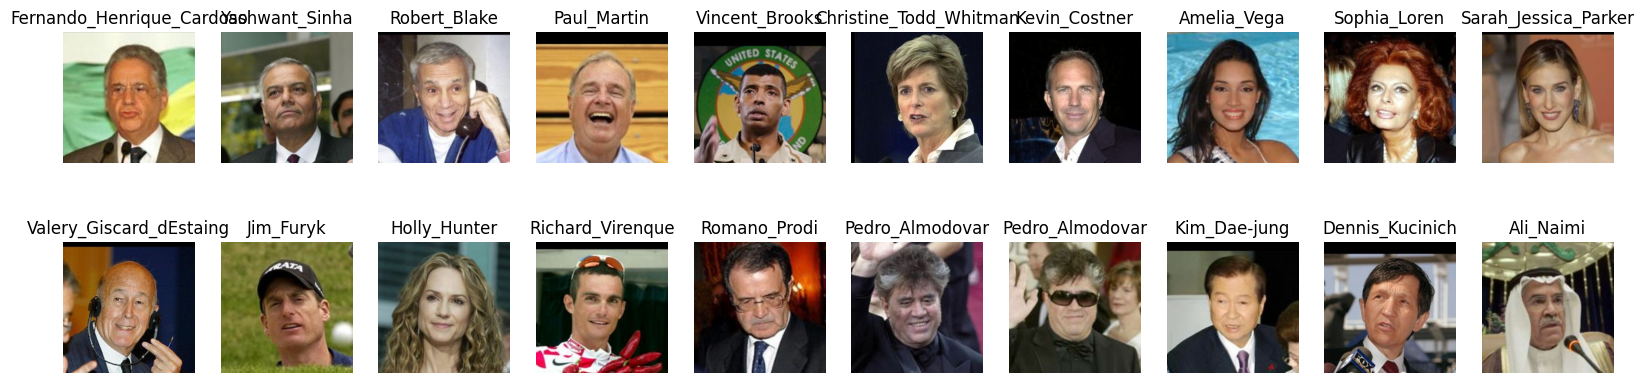

In [ ]:
images, labels = next(iter(train_dataloader))
class_names = train_ds.classes
denorm_images = [denormalize_image(img) for img in images]

fig = plt.figure(figsize=(20, 5))

for i in range(20):
    ax = fig.add_subplot(2, 10, i+1)
    image = denorm_images[i].numpy().transpose((1, 2, 0))

    plt.imshow(image)

    plt.title(class_names[labels[i]])

    plt.axis('off')
plt.show()

Наконец, следует вывести распределение фотографий по людям и убедиться, что для каждого человека действительно предствалено 6-9 фотографий.

In [ ]:
from collections import Counter

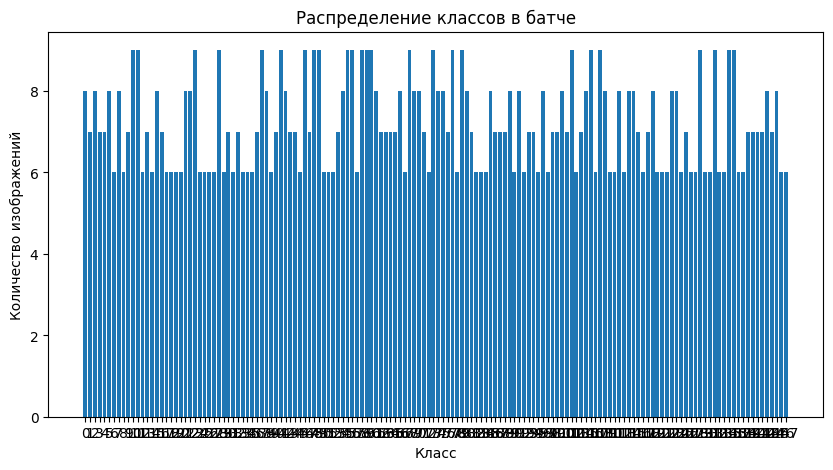

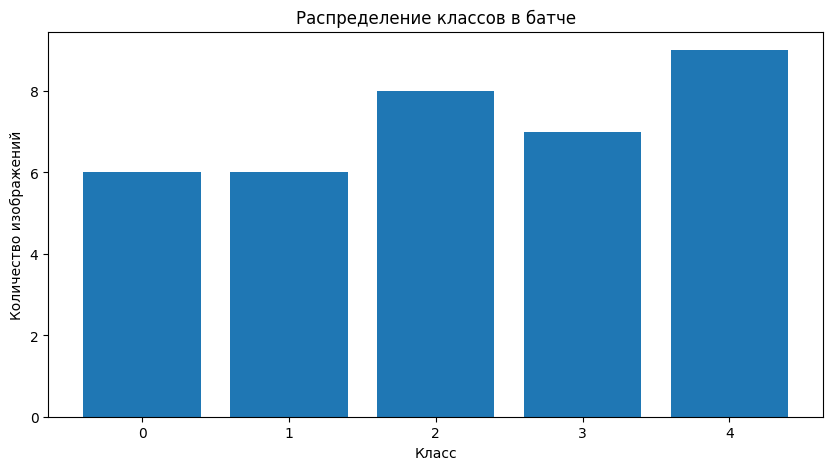

In [ ]:
def show_class_distribtion(targets):
    counts = Counter(targets)

    existing_classes = sorted(counts.keys())
    class_counts = [counts[klass] for klass in existing_classes]

    plt.figure(figsize=(10, 5))
    plt.bar(existing_classes, class_counts)

    plt.xlabel('Класс')
    plt.ylabel('Количество изображений')
    plt.title('Распределение классов в батче')
    plt.xticks(existing_classes)
    plt.show()

show_class_distribtion(train_ds.targets)
show_class_distribtion(test_ds.targets)

##### [0 баллов] Задание 1.2. Датасет пар.

Как было сказано ранее, мы будем обучать модели предсказывать, разные ли люди изображены на фотографиях. Для этого нам надо научиться формировать пары фотографий и целевую переменную из двух классов: 0 и 1. \
Класс 0 означает, что это фотографии одного человека. \
Класс 1 означает фотографии разных людей. \
 \
К счастью, весь датасет уже написан.

In [ ]:
class PairDataset(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        self.targets = [ self._get_target(i) for i in tqdm.trange(len(self)) ]

    def _idx1(self, idx):
        return idx % len(self.dataset)

    def _idx2(self, idx):
        return idx // len(self.dataset)

    def _get_target(self, idx):
        return int(self.dataset.targets[self._idx1(idx)] != self.dataset.targets[self._idx2(idx)])

    def __len__(self):
        return len(self.dataset) ** 2

    def __getitem__(self, idx):
        image1, label1 = self.dataset[self._idx1(idx)]
        image2, label2 = self.dataset[self._idx2(idx)]
        image1, label1 = image1.to(device), torch.tensor(label1).to(device)
        image2, label2 = image2.to(device), torch.tensor(label2).to(device)
        return image1, image2, int(label1 != label2)

train_pairs = PairDataset(train_ds)
test_pairs = PairDataset(test_ds)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1296/1296 [00:00<?, ?it/s]


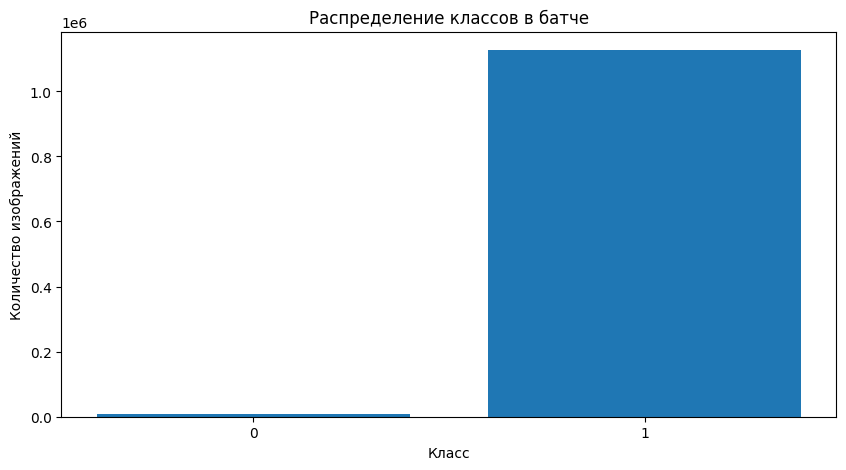

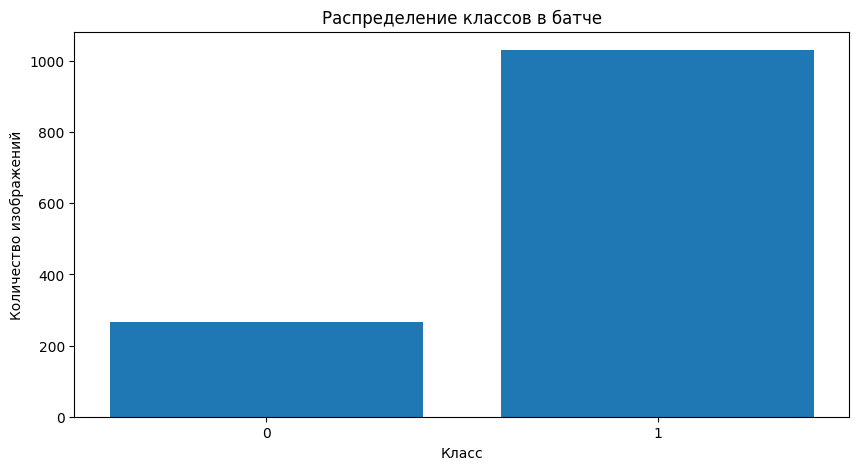

In [ ]:
show_class_distribtion(train_pairs.targets)
show_class_distribtion(test_pairs.targets)

Легко видеть, что пар фотографий разных людей гораздо больше, чем пар фотографий одного человека. Это вполне ожидаемо, но, если не предпринять мер, ведет к двум проблемам:
1. Метрика качества предсказаний должна учитывать дисбаланс классов. В частности, accuracy нам не подойдёт. А использовать будем известный из курса машинного обучения AUC-ROC.
2. Нужно "подтюнить" даталоадер тренировочных данных, чтобы в каждый батч попадало примерно одинаковое количество фотографий каждого класса. Иначе победить деградацию модели к "всегда 1" будет очень сложно.

##### [1 балл] Задание 1.3. Стратифицированный даталоадер.

Для начала решим вторую проблему. Нужно сделать такой даталоадер, чтобы в каждом батче количество элементов класса "0" совпадало с количеством элементов класса "1".

Как известно, стандартный класс `DataLoader` в torch имеет много параметров. В частности, параметр `sampler` позволяет гибко управлять выдачей. Изучите [документацию](https://docs.pytorch.org/docs/stable/data.html#data-loading-order-and-sampler) и реализуйте свой семплер, который решит проблему.

В `pytorch_metric_learning` уже есть готовая реализация того, что нам нужно. Вы можете её найти и использовать. Но в таком случае __максимальный балл за это задание - 0.4__.

In [ ]:
from torch.utils.data.sampler import Sampler

In [ ]:
from typing import List, Iterator
from math import ceil

class BalancedBatchSampler(Sampler):
    def __init__(self, dataset, batch_size):
        self.dataset = dataset
        self.batch_size = batch_size

        positives = [i for i, x in enumerate(self.dataset) if x == 0]
        negatives = [i for i, x in enumerate(self.dataset) if x != 0]

        set_random_seed()
        random.shuffle(positives)
        random.shuffle(negatives)

        negatives = negatives[:len(positives)]
        self.items = [x for i in zip(negatives, positives) for x in i]


    def __iter__(self):
        for i in range(0, len(self.items), self.batch_size):
            b = self.items[i:i+self.batch_size]
            yield b

    def __len__(self):
        return ceil(len(self.items)/self.batch_size)

In [ ]:
train_pairs_sampler = BalancedBatchSampler(train_pairs.targets, 32)

In [ ]:
train_pairs_loader = torch.utils.data.DataLoader(train_pairs, batch_sampler = train_pairs_sampler)
test_pairs_loader = torch.utils.data.DataLoader(test_pairs, batch_size = 64, shuffle = False)

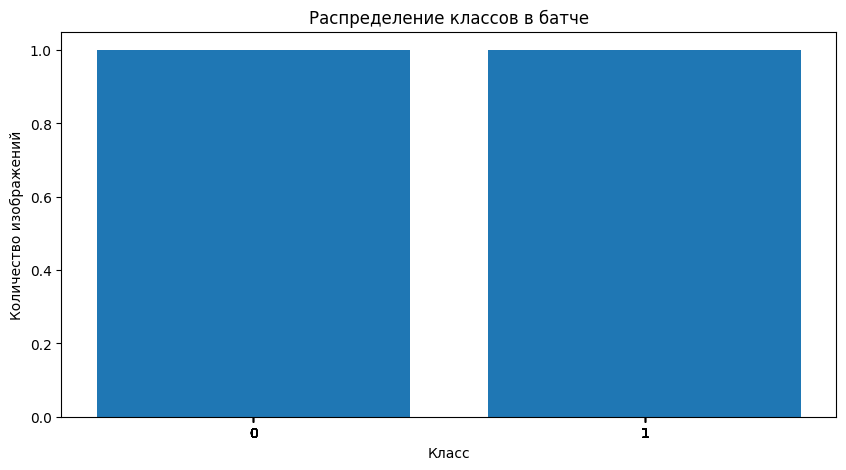

In [ ]:
show_class_distribtion(next(iter(train_pairs_loader))[2])

### [3.5 балла] Часть 2. Классификация.

Начнём с простого: попробуем решить проблему как обычную задачу бинарной классификации. Реализуйте и обучите обычную свёрточную сеть, которая принимает два набора фотографий и предсказывает вероятность, что это фотографии разных людей.

##### [1 балл] Задание 2.1. Модель классификации.

Сначала нужно реализовать модель. В `forward` необходимо принять два батча фотографий. `i`-e число в выводе `forward` должно быть предсказанием для пары из `i`-й фотографии `image1` и `i`-й фотографии `image2`. Подумайте, как это сделать. Возможно, стоит как-нибудь склеить `image1` и `image2`? Или склеить эмбеддинги? А может быть нужен какой-то трешхолд?

Вы вольны использовать любую архитектуру сети. Ассерт в конце ячейки поможет вам убедиться, что модель теоретически делает то, что нужно.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
class ClassificationNet1(torch.nn.Module):
    def __init__(self):
        super(ClassificationNet1, self).__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Полносвязные слои классификатора
        self.fc_out = nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(16 * 125 * 125, 128),
            torch.nn.ReLU(),
        )

        self.proba = nn.Sequential(
            torch.nn.Linear(128 * 2, 32),
            torch.nn.ReLU(),
            torch.nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, image1, image2):
        m1 = self.block1(image1)
        emb1 = self.fc_out(m1)
        m2 = self.block1(image2)
        emb2 = self.fc_out(m2)

        output = self.proba(torch.cat((emb1, emb2), dim=1)).squeeze(1)

        return output

model = ClassificationNet1().to('cuda')
batch = next(iter(train_pairs_loader))
inputs1, inputs2 = batch[:2]

inputs1 = inputs1.to('cuda')
inputs2 = inputs2.to('cuda')

output = model(inputs1, inputs2)

assert output.shape == (32,)

In [ ]:
class ClassificationNet2(torch.nn.Module):
    def __init__(self):
        super(ClassificationNet2, self).__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding='same'),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.fc_out = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(out_features=128),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.proba = nn.Sequential(
            nn.Linear(128 * 2, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, image1, image2):
        m1 = self.block1(image1)
        emb1 = self.fc_out(m1)
        m2 = self.block1(image2)
        emb2 = self.fc_out(m2)
        output = self.proba(torch.cat((emb1, emb2), dim=1)).squeeze(1)
        return output

model = ClassificationNet2().to('cuda')
batch = next(iter(train_pairs_loader))
inputs1, inputs2 = batch[:2]

inputs1 = inputs1.to('cuda')
inputs2 = inputs2.to('cuda')

output = model(inputs1, inputs2)

assert output.shape == (32,)

##### [2 балла] Задание 2.2. Обучение.

Теперь обучите свою модель и добейтесь приемлемого качества. Балл за это задание вычисляется по формуле:

$$ clamp(0, 2.5 \cdot \dfrac{AucRoc - 0.6}{0.2}, 2.5) $$

То есть, для получения полного балла за это задание необходимо добиться AUC-ROC `0.8`

__При использовани предобученных моделей, балл за это задание умножается на 0.5__ (то есть, не более 1)

In [ ]:
from torch import nn, optim

In [ ]:
from tqdm import tqdm

In [ ]:
torch.backends.cudnn.benchmark = True

def train(model, criterion, optimizer, train_dataloader, n_epochs=2):
    set_random_seed()
    train_loss = []

    for epoch in range(n_epochs):
        correct_predictions = 0   # Правильные предсказания
        total_samples = 0         # Всего выборок
        train_epoch_loss = torch.empty(0, device=device)
        model.train()

        for img1, img2, labels in tqdm(train_dataloader, desc=f"Training epoch {epoch}", leave=False):
            img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)

            outputs = model(img1, img2)

            loss = criterion(outputs, labels.float())
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            predictions = (outputs > 0.5).float()  # Класс 1, если вероятность >= 0.5
            correct_predictions += ((predictions == labels).sum()).item()
            total_samples += len(labels)

            train_epoch_loss = torch.cat((train_epoch_loss, loss.unsqueeze(0)), dim=0)

        avg_accuracy = correct_predictions / total_samples * 100
        avg_train_loss = train_epoch_loss.mean().item()
        train_loss.append(avg_train_loss)

        print(f"Epoch [{epoch + 1}/{n_epochs}] | Train Loss: {avg_train_loss:.4f}, Accuracy: {avg_accuracy:.2f}%")

In [ ]:
def get_score(auc_roc):
    return max(0, min(2.5 * (auc_roc - 0.6) / 0.2, 2.5))

def get_auc_roc(your_model):
    preds = []
    targets = []
    your_model.eval()
    for images1, images2, labels in tqdm(test_pairs_loader):
        with torch.no_grad():
            output = your_model(images1.to(device), images2.to(device))
        preds.extend(output.detach().cpu().tolist())
        targets.extend(labels.detach().cpu().tolist())
    preds = np.array(preds)
    targets = np.array(targets)
    return sklearn.metrics.roc_auc_score(targets, preds)


In [ ]:
set_random_seed()
model1 = ClassificationNet1().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model1.parameters(), lr=0.001)

set_random_seed()
train(model=model1, criterion=criterion,
      optimizer=optimizer, train_dataloader=train_pairs_loader, n_epochs=5)

roc = get_auc_roc(model1)
print(roc)
get_score(get_auc_roc(model1))

Epoch [1/5] | Train Loss: 7.4802, Accuracy: 56.18%


Epoch [2/5] | Train Loss: 0.5630, Accuracy: 70.04%


Epoch [3/5] | Train Loss: 0.4114, Accuracy: 80.61%


Epoch [4/5] | Train Loss: 0.2964, Accuracy: 87.52%


Epoch [5/5] | Train Loss: 0.2268, Accuracy: 90.92%


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [00:02<00:00,  7.69it/s]


0.8793598072852032


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [00:02<00:00,  7.28it/s]


2.5

In [ ]:
set_random_seed()
model2 = ClassificationNet2().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model2.parameters(), lr=0.001)

set_random_seed()
train(model=model2, criterion=criterion,
      optimizer=optimizer, train_dataloader=train_pairs_loader, n_epochs=5)

roc = get_auc_roc(model2)
print(roc)
get_score(get_auc_roc(model2))

Epoch [1/5] | Train Loss: 0.7021, Accuracy: 54.03%


Epoch [2/5] | Train Loss: 0.6542, Accuracy: 61.76%


Epoch [3/5] | Train Loss: 0.5525, Accuracy: 71.15%


Epoch [4/5] | Train Loss: 0.4189, Accuracy: 80.79%


Epoch [5/5] | Train Loss: 0.3413, Accuracy: 85.74%


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [00:03<00:00,  6.88it/s]


0.7741404482078984


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [00:03<00:00,  6.91it/s]


2.17675560259873

##### [0.5 балла] Задание 2.3. Анализ и отчет.

Опишите свои эксперименты. Проанализируйте результаты. Почему результаты получились не очень хорошими? Может быть, решать задачу через бинарную классификацию - не лучшая идея? Приведите не менее 3 аргументов, почему это так.

Выводы:

Вначале была обучена простая модель, состоящая всего из одного сверточного слоя. При количестве эпох, равном 10 значение auc-roc составило 0.89, что уже дает максимальный балл за задание. Полагаю, что в данном случае модель находила более простые паттерны изображений и, соответственно, обучалась быстрее.

Второй была реализована более сложная модель, содержащая два сверточных слоя. Также был подключен Dropout и MaxPooling слои. Эта модель обучалась немного дольше. Полученное качество при этом снизилось до auc_roc = 0.77, что демонстрирует отрицательную динамику. Во время обучения я экспериментировала с архитектурой и обнаружила, что при большом кол-ве сверточных слоев с большим кол-вом параметров (при этом я добавляла batch-нормализацию!) модель не обучалась (возможно была проблема с затуханием градиентов). Также попробовала использовать LazyLinear слой, где не нужно указывать кол-во input-нейронов.

Блок *proba* для обоих моделей был одинаков.

Причины, почему решать эту задачу через бинарную классификацию - не лучшая идея:

1. Модель не учится различать насколько лицо одного человека схоже/разное относительно остальных изображений людей в датасете. То есть для нее основной задачей является определение "непохожести" друг на друга пары полученных фотографий. Соответственно, она анализирует каждую полученную пару фото в отрыве от остальных, что не дает ей формировать общее множество признаков.

2. Фаактором, возможно, не влияющим на результат, но, тем не менее, значимым, является кол-во затраченного времени на реализацию. Надо было написать рукописный сэмплер (потому что дисбаланс классов никто не отменял), руками написать датасеты, придумать архитектуру и механизм сравнения пары изображений. Все это долго, неэффективно и затратно.

3. Бинарная классификация может привести к тому, что не будет правильно классифицировать фотографии одного и того же человека, снятые в разный период времени (с измененным имиджем, например). То есть у человека может поменяться цвет волос, одежда, даже глаз и модель не сможет определить, что человек, изображенный на двух фотографиях один и тот же.

### [5 баллов] Часть 3. Распознавание лиц.

Теперь попробуем использовать более хитрые методы, которые лучше подходят для решаемой задачи. В частности, триплетную функцию потерь. Далее наша модель будет не предсказывать вероятность для двух картинок, а формировать эмбеддинги для одной картинки таким образом, чтобы эмбеддинги фотографий одного человека были близки, а разных людей - далеки.

##### [2 балла] Задание 3.1. Триплетная функция потерь.

Напомним теорию. Пусть $A$ - произвольное изображение; $P$ - изображение того же человека (позитивный пример); $N$ - изображение любого другого человека (негативный пример); $f$ - наша нейронная сеть; $\alpha$ - гиперпараметр, отвечающий за желаемый “отступ” – расстояние между латентными представлениями изображений разных людей. Тогда функционал ошибки определяется следующим образом:

$$ L(A, P, N) = max(||f(A) - f(P)|| - ||f(A) - f(N)|| + \alpha, 0) $$

В этом задании вам необходимо реализовать этот функционал. Для удобства в дальнейшем, предлагается сразу реализовать batch-версию. Таким образом, на входе должно быть 2 параметра:
- Набор эмбеддингов размера (batch_size, embedding_size)
- Набор классов (номера людей, чьи это фотографии) размера (batch_size)

Ваша функция должна найти все тройки $(A, P, N)$ и вычислить лосс для них.

В `pytorch_metric_learning` уже есть готовая реализация. Вы можете её найти и использовать. Но в таком случае __максимальный балл за это задание - 0.5__.

In [ ]:
class Criterion(nn.Module):
    def __init__(self, alpha=0.25):
        super().__init__()
        self.alpha = alpha

    def forward(self, embeddings, labels):
        batch_size = embeddings.size(0)
        total_loss = torch.tensor(0.0, device=embeddings.device, requires_grad=True)
        count = 0

        for i in range(batch_size):
            fA = embeddings[i]
            labelA = labels[i]

            positive_mask = (labels == labelA)
            negative_mask = (labels != labelA)
            positive_mask[i] = False

            positive_indices = torch.where(positive_mask)[0]
            negative_indices = torch.where(negative_mask)[0]

            if len(positive_indices) == 0 or len(negative_indices) == 0:
                continue

            for p_idx in positive_indices:
                for n_idx in negative_indices:
                    dist_pos = torch.norm(embeddings[p_idx] - fA)
                    dist_neg = torch.norm(embeddings[n_idx] - fA)
                    loss_value = F.relu(dist_pos - dist_neg + self.alpha)
                    total_loss = total_loss + loss_value
                    count += 1

        if count == 0:
            return embeddings.sum() * 0
        return total_loss / count

In [ ]:
# Вы можете использовать этот ассерт в качестве теста
embeddings = torch.tensor([
    [ 1., 2, 3 ],
    [ 1, 3, 4 ],
    [ 4, 5, 6 ]
])
labels = torch.tensor([ 1., 2, 1 ])
criterion = Criterion()
assert (criterion(embeddings, labels) - 2.6775) < 1e-4

##### [3 балла] Задание 3.2. Обучение.

Теперь обучите модель и добейтесь приемлемого качества. Балл за это задание вычисляется по формуле:

$$ clamp(0, 3 \cdot \dfrac{AucRoc - 0.8}{0.15}, 3) $$

То есть, для получения полного балла за это задание необходимо добиться AUC-ROC `0.95`

При необходимости, вы можете улучшить функцию потерь. Например, учитывать не все тройки, а только "сложные", как это умеет делать реализация в `pytorch_metric_learning`. Также подумайте над даталоадером. Возможно, имеет смысл брать в батч одинаковое количество фотографий каждого человека по аналгии с заданием 1.3? Тем не менее имейте в виду, что для получения полного балла за задание, вы должны реализовать все модификации самостоятельно, а не использовать готовые.

__При использовани предобученных моделей, балл за это задание умножается на 0.5__ (то есть, не более 1.5) \
__При использовани pytorch_metric_learning, балл за это задание уменьшается на 0.5 за каждое использование__

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
set_random_seed(42)

class MyModel_Triple(nn.Module):
    def __init__(self):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.SiLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.SiLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.SiLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.SiLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.LazyLinear(out_features=128),
            nn.BatchNorm1d(128),
        )

    def forward(self, img):
        emb = self.block1(img)
        return F.normalize(emb, p=2, dim=1)

In [ ]:
model = MyModel_Triple().to(device)
criterion = Criterion()

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

set_random_seed(42)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

set_random_seed(42)

for epoch in range(20):
    model.train()
    total_loss = 0
    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        embeddings = model(images)
        loss = criterion(embeddings, labels)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        total_loss += loss.item()

    scheduler.step()
    print(f"Эпоха {epoch+1}: Loss={total_loss/len(train_loader):.4f}")

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 34/34 [00:05<00:00,  6.05it/s]
C:\Users\Софья\myenv\Lib\site-packages\torch\optim\lr_scheduler.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Эпоха 1: Loss=0.2086


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 34/34 [00:05<00:00,  6.27it/s]


Эпоха 2: Loss=0.2202


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 34/34 [00:05<00:00,  6.72it/s]


...

Эпоха 18: Loss=0.0651


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 34/34 [00:05<00:00,  6.70it/s]


Эпоха 19: Loss=0.0758


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 34/34 [00:05<00:00,  6.31it/s]

Эпоха 20: Loss=0.0587


In [ ]:
def get_score(auc_roc):
    return max(0, min(3 * (auc_roc - 0.8) / 0.15, 3))

def get_auc_roc(your_model):
    preds = []
    targets = []
    your_model.eval()
    for images1, images2, labels in tqdm(test_pairs_loader):
        with torch.no_grad():
            emb1 = your_model(images1.to(device))
            emb2 = your_model(images2.to(device))
            dist = ((emb1 - emb2) ** 2).sum(dim = 1)
        preds.extend(dist.detach().cpu().tolist())
        targets.extend(labels.detach().cpu().tolist())
    preds = np.array(preds)
    targets = np.array(targets)
    return sklearn.metrics.roc_auc_score(targets, preds)

roc = get_auc_roc(model)
print(roc)
get_score(roc)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [00:04<00:00,  5.06it/s]

0.9227534856558872


2.4550697131177435

Обзор экспериментов:

1. Использовала новую функцию активации - SiLU. Так как при использовании ReLU качество не удовлетворяло заданию. Прочла в интернете, что эта функция более устойчива при работе с небольшими датасетами. В нашем случае подошла идеально.

2. Добавлена нормализация по батчам чтобы не затухал градиент. При обучении помогло, так как сверточных слоев получилось достаточно много (относительно экспериментов второго задания).

3. Всего использовала 5 сверточных слоев.

4. Добавила __lr_scheduler__, который должен плавно уменьшать шаг градиента ближе в минимуму, так мы уменьшаем шанс проскочить минимум и застрять в каком-нибудь локальном минимуме.

Итоговое качество получилось auc_roc = **0.92**

##### [0.1 балла] Бонус: распознай себя

В качестве бонуса, загрузите свою фотографию (можно не одну), пропустите ее через модель и определите, на кого из известных людей, по мнению модели, вы больше всего похоже.